In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
import os, shutil

os.makedirs("data", exist_ok=True)

# check both possible upload locations
if os.path.exists("iris.csv"):
    shutil.move("iris.csv", "data/iris.csv")
elif os.path.exists("sample_data/iris.csv"):
    shutil.move("sample_data/iris.csv", "data/iris.csv")

print(os.listdir("data"))

['iris.csv']


In [3]:
df = pd.read_csv("data/iris.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df["species"].value_counts())
df.head()


Shape: (150, 5)
Missing values: 0
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (120, 4) Test: (30, 4)


In [5]:
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)
pred_full = tree_full.predict(X_test)

print("Unpruned tree depth:", tree_full.get_depth())
print("Unpruned accuracy:", accuracy_score(y_test, pred_full))


Unpruned tree depth: 5
Unpruned accuracy: 0.9333333333333333


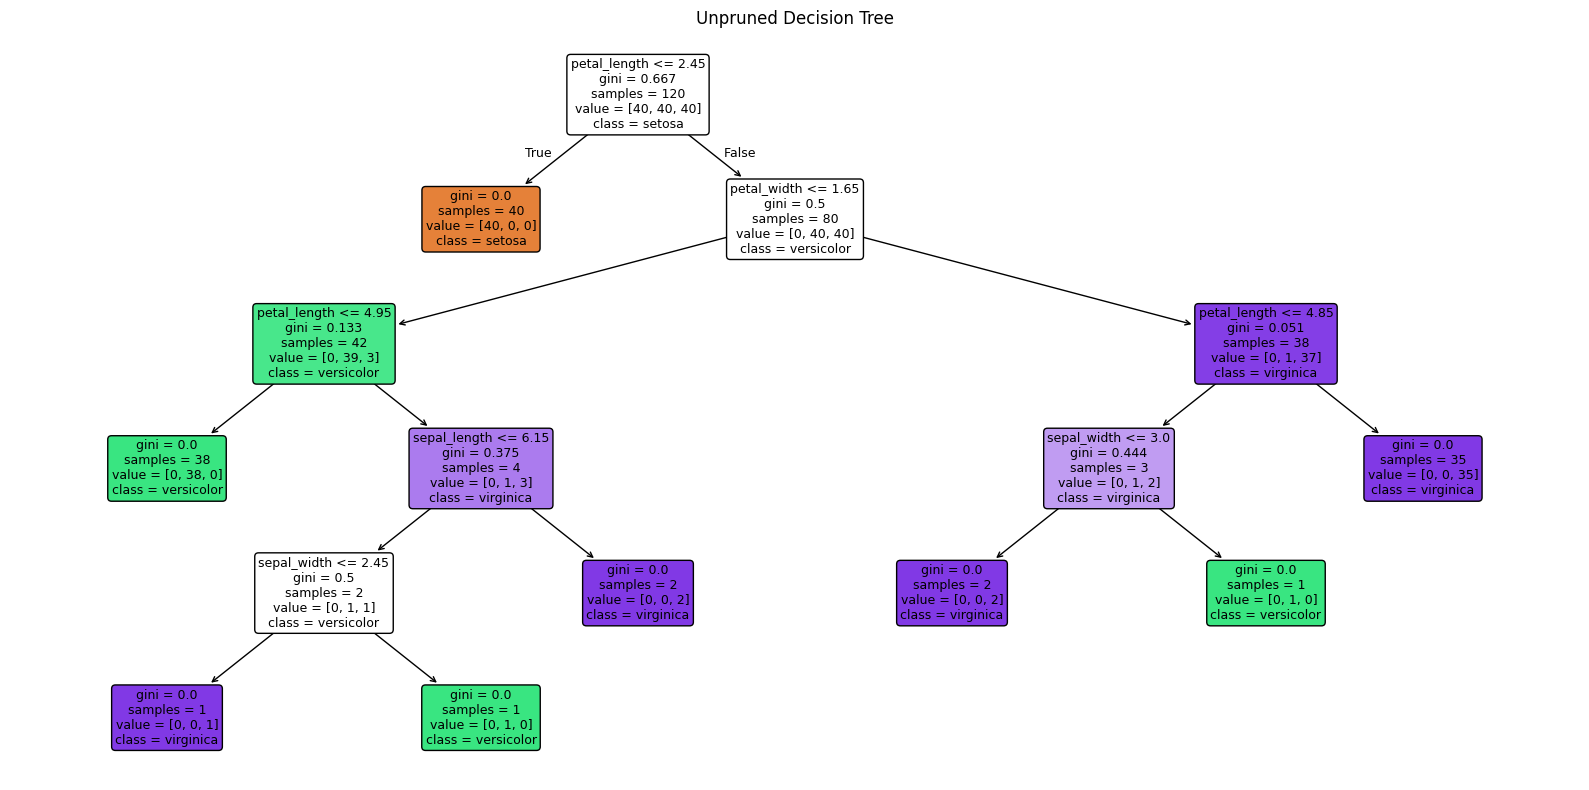

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(tree_full, feature_names=X.columns, class_names=tree_full.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Unpruned Decision Tree")
plt.tight_layout()
plt.show()


Pruned tree depth: 3


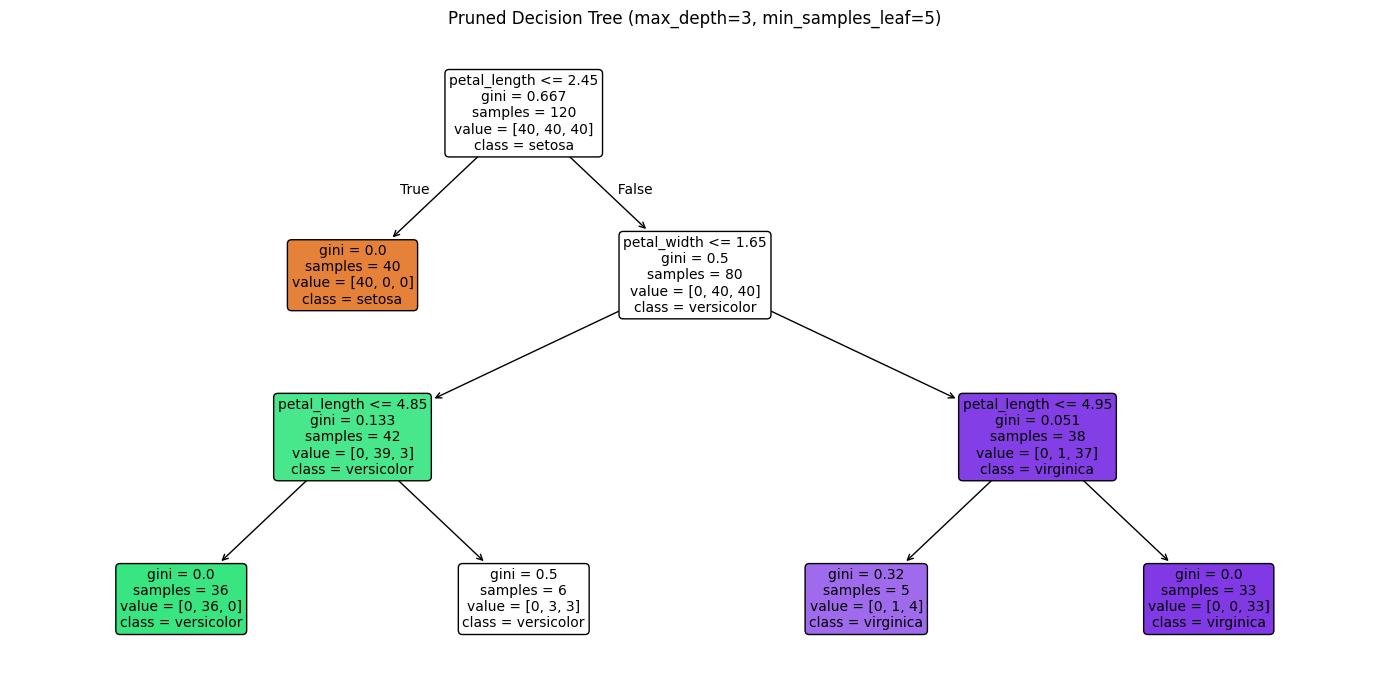

In [7]:
tree_pruned = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)
pred_pruned = tree_pruned.predict(X_test)

print("Pruned tree depth:", tree_pruned.get_depth())

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree_pruned, feature_names=X.columns, class_names=tree_pruned.classes_,
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Pruned Decision Tree (max_depth=3, min_samples_leaf=5)")
plt.tight_layout()
plt.show()


In [8]:
acc = accuracy_score(y_test, pred_pruned)
f1 = f1_score(y_test, pred_pruned, average="weighted")

print(f"Pruned Accuracy: {acc:.4f}")
print(f"Pruned Weighted F1-score: {f1:.4f}\n")
print(classification_report(y_test, pred_pruned))


Pruned Accuracy: 0.9333
Pruned Weighted F1-score: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



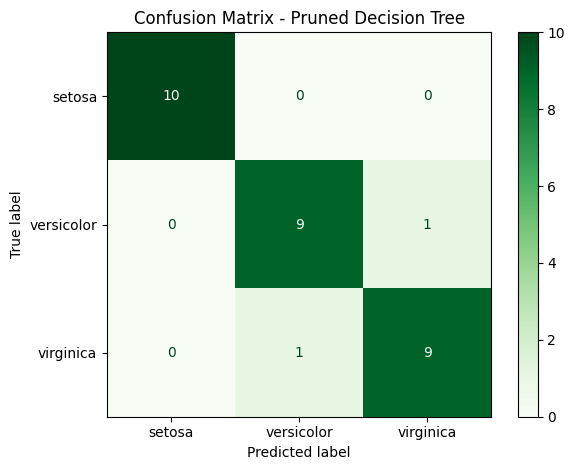

In [9]:
cm = confusion_matrix(y_test, pred_pruned, labels=tree_pruned.classes_)
ConfusionMatrixDisplay(cm, display_labels=tree_pruned.classes_).plot(cmap="Greens")
plt.title("Confusion Matrix - Pruned Decision Tree")
plt.tight_layout()
plt.show()
